<a href="https://colab.research.google.com/github/shroukadel457-cell/autoworth-ai/blob/main/AutoWorth_AI_Final22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Setup

In [ ]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


RANDOM_STATE = 42

---
# 1. Load & Understand the Data

We load the 9 manufacturer files, create a **`Make`** column for each one *before* combining them (the files themselves do not say which brand they belong to), and inspect each file:
size, columns, data types, missing values, duplicates, numerical statistics and categorical values.

> Note: Hyundai's file calls the tax column `tax(£)` while all other files call it `tax`, so we rename it to keep the columns consistent.

In [ ]:
DATA_DIR = "."

FILES = {
    "Audi": "audi.csv", "BMW": "bmw.csv", "Ford": "ford.csv", "Hyundai": "hyundi.csv",
    "Mercedes": "merc.csv", "Skoda": "skoda.csv", "Toyota": "toyota.csv",
    "Vauxhall": "vauxhall.csv", "Volkswagen": "vw.csv",
}

frames = {}
for make, filename in FILES.items():
    part = pd.read_csv(f"{DATA_DIR}/{filename}")
    part = part.rename(columns={"tax(£)": "tax"})
    part["Make"] = make                      # new Make column, created BEFORE combining
    frames[make] = part

print("Columns identical in all files:", all(set(p.columns) == set(frames["Audi"].columns) for p in frames.values()))
print("Columns:", list(frames["Audi"].columns))

Columns identical in all files: True
Columns: ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'Make']


### 1.1 Size, missing values and duplicates — per manufacturer

In [ ]:
summary = pd.DataFrame({
    make: {"rows": p.shape[0], "columns": p.shape[1],
           "missing values": int(p.isnull().sum().sum()),
           "duplicate rows": int(p.duplicated().sum())}
    for make, p in frames.items()
}).T
summary.loc["TOTAL"] = summary.sum()
display(summary)

,rows,columns,missing values,duplicate rows
Audi,10668,10,0,103
BMW,10781,10,0,117
Ford,17965,10,0,154
Hyundai,4860,10,0,86
Mercedes,13119,10,0,259
Skoda,6267,10,0,79
Toyota,6738,10,0,39
Vauxhall,13632,10,0,374
Volkswagen,15157,10,0,264
TOTAL,99187,90,0,1475


### 1.2 Data types and numerical statistics

In [ ]:
print("Data types (same in every file):")
print(frames["Audi"].dtypes.to_string())

num_cols = ["year", "price", "mileage", "tax", "mpg", "engineSize"]
ranges = pd.DataFrame({
    make: pd.concat([p[num_cols].min().add_suffix(" (min)"), p[num_cols].max().add_suffix(" (max)")])
    for make, p in frames.items()
}).T
print("\nMinimum and maximum of every numeric column, per manufacturer:")
display(ranges)

print("Full numerical statistics of one file (Audi) — use inspect(make) for any other:")
def inspect(make):
    return frames[make].describe().T.round(2)
display(inspect("Audi"))

Data types (same in every file):
model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
Make             object

Minimum and maximum of every numeric column, per manufacturer:


,year (min),price (min),mileage (min),tax (min),mpg (min),engineSize (min),year (max),price (max),mileage (max),tax (max),mpg (max),engineSize (max)
Audi,1997.0,1490.0,1.0,0.0,18.9,0.0,2020.0,145000.0,323000.0,580.0,188.3,6.3
BMW,1996.0,1200.0,1.0,0.0,5.5,0.0,2020.0,123456.0,214000.0,580.0,470.8,6.6
Ford,1996.0,495.0,1.0,0.0,20.8,0.0,2060.0,54995.0,177644.0,580.0,201.8,5.0
Hyundai,2000.0,1200.0,1.0,0.0,1.1,0.0,2020.0,92000.0,138000.0,555.0,256.8,2.9
Mercedes,1970.0,650.0,1.0,0.0,1.1,0.0,2020.0,159999.0,259000.0,580.0,217.3,6.2
Skoda,2004.0,995.0,5.0,0.0,30.1,0.0,2020.0,91874.0,300000.0,325.0,201.8,2.5
Toyota,1998.0,850.0,2.0,0.0,2.8,0.0,2020.0,59995.0,174419.0,565.0,235.0,4.5
Vauxhall,1970.0,450.0,1.0,0.0,25.9,0.0,2020.0,52489.0,279000.0,565.0,235.4,3.2
Volkswagen,2000.0,899.0,1.0,0.0,0.3,0.0,2020.0,69994.0,212000.0,580.0,188.3,3.2


Full numerical statistics of one file (Audi) — use inspect(make) for any other:


,count,mean,std,min,25%,50%,75%,max
year,10668.0,2017.10,2.17,1997.0,2016.00,2017.0,2019.0,2020.0
price,10668.0,22896.69,11714.84,1490.0,15130.75,20200.0,27990.0,145000.0
mileage,10668.0,24827.24,23505.26,1.0,5968.75,19000.0,36464.5,323000.0
tax,10668.0,126.01,67.17,0.0,125.00,145.0,145.0,580.0
mpg,10668.0,50.77,12.95,18.9,40.90,49.6,58.9,188.3
engineSize,10668.0,1.93,0.60,0.0,1.50,2.0,2.0,6.3


### 1.3 Categorical values

In [ ]:
cat_summary = pd.DataFrame({
    make: {"unique models": p["model"].nunique(),
           "transmissions": ", ".join(sorted(p["transmission"].unique())),
           "fuel types": ", ".join(sorted(p["fuelType"].unique()))}
    for make, p in frames.items()
}).T
display(cat_summary)

print("Example — the most common Audi models:")
print(frames["Audi"]["model"].value_counts().head(8).to_string())

,unique models,transmissions,fuel types
Audi,26,"Automatic, Manual, Semi-Auto","Diesel, Hybrid, Petrol"
BMW,24,"Automatic, Manual, Semi-Auto","Diesel, Electric, Hybrid, Other, Petrol"
Ford,23,"Automatic, Manual, Semi-Auto","Diesel, Electric, Hybrid, Other, Petrol"
Hyundai,16,"Automatic, Manual, Other, Semi-Auto","Diesel, Hybrid, Other, Petrol"
Mercedes,27,"Automatic, Manual, Other, Semi-Auto","Diesel, Hybrid, Other, Petrol"
Skoda,12,"Automatic, Manual, Other, Semi-Auto","Diesel, Hybrid, Other, Petrol"
Toyota,18,"Automatic, Manual, Other, Semi-Auto","Diesel, Hybrid, Other, Petrol"
Vauxhall,22,"Automatic, Manual, Other, Semi-Auto","Diesel, Electric, Hybrid, Other, Petrol"
Volkswagen,27,"Automatic, Manual, Semi-Auto","Diesel, Hybrid, Other, Petrol"


Example — the most common Audi models:
model
A3    1929
Q3    1417
A4    1381
A1    1347
A5     882
Q5     877
Q2     822
A6     748


**What we notice in the raw files**

- No missing values in any file — but that does **not** mean the data is clean (see the min/max table above).
- Suspicious values already visible: a Ford with `year = 2060`, a Mercedes with `year = 1970`, `engineSize = 0` in every file, and `mpg` values as low as 0.3 or as high as several hundred.
- Some manufacturers contain very rare categories (`Other` transmission, `Electric` / `Other` fuel).
- Several files contain duplicated rows, and some Mercedes model names start with a space (e.g. `" C Class"`).

These problems are investigated in Section 3.

---
# 2. Combine the Data

We stack the 9 files into one dataset and repeat the checks on the combined data: missing values, duplicates, data types and suspicious values.

In [ ]:
raw = pd.concat(frames.values(), ignore_index=True)

print("Combined dataset size:", raw.shape)
print("Missing values       :", int(raw.isnull().sum().sum()))
print("Duplicate rows       :", int(raw.duplicated().sum()))
print("\nData types:")
print(raw.dtypes.to_string())

checks = {
    "price <= 0":                  raw["price"] <= 0,
    "year < 1996 or year > 2020":  (raw["year"] < 1996) | (raw["year"] > 2020),
    "mileage < 0":                 raw["mileage"] < 0,
    "tax < 0":                     raw["tax"] < 0,
    "mpg < 10":                    raw["mpg"] < 10,
    "mpg > 150":                   raw["mpg"] > 150,
    "engineSize == 0":             raw["engineSize"] == 0,
}
print("\nSuspicious or unrealistic values (number of rows):")
display(pd.Series({name: int(cond.sum()) for name, cond in checks.items()}).to_frame("rows"))

Combined dataset size: (99187, 10)
Missing values       : 0
Duplicate rows       : 1475

Data types:
model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
Make             object

Suspicious or unrealistic values (number of rows):


,rows
price <= 0,0
year < 1996 or year > 2020,3
mileage < 0,0
tax < 0,0
mpg < 10,34
mpg > 150,278
engineSize == 0,273


**Result:** 99,187 rows and 10 columns, no missing values and correct data types — but **1,475 duplicated rows** and several suspicious values (impossible years, `engineSize = 0`, impossible `mpg`).
Each of these is investigated before deciding what to do with it.

---
# 3. Data Cleaning

**Rule of this project: do not simply delete suspicious values — investigate first, then decide, and explain why.**
For every problem we (1) look at the evidence, (2) decide, (3) apply the fix. A summary table closes the section.

We work on a copy (`df`) so the raw combined data stays available for comparison.

### 3.1 Inconsistent categories

In [ ]:
df = raw.copy()

# remove leading/trailing spaces from every text column
for col in ["Make", "model", "transmission", "fuelType"]:
    df[col] = df[col].str.strip()

print("Unique models after stripping spaces:", df["model"].nunique())
print("transmission:", sorted(df["transmission"].unique()))
print("fuelType    :", sorted(df["fuelType"].unique()))

# are there names that only differ by upper/lower case inside the same make?
names = df.groupby("Make")["model"].unique()
clashes = {mk: sorted(m) for mk, ms in names.items()
           for m in [[x for x in ms if sum(y.lower() == x.lower() for y in ms) > 1]] if m}
print("Case-only variants of the same model:", clashes if clashes else "none")

Unique models after stripping spaces: 195
transmission: ['Automatic', 'Manual', 'Other', 'Semi-Auto']
fuelType    : ['Diesel', 'Electric', 'Hybrid', 'Other', 'Petrol']
Case-only variants of the same model: none


**Decision:** removing the spaces makes model names consistent (e.g. `" C Class"` → `"C Class"`). `transmission` and `fuelType` have no spelling variants (no `petrol` vs `Petrol`), so nothing else needs fixing.

### 3.2 Duplicate rows

In [ ]:
dups = df[df.duplicated(keep=False)].sort_values(list(df.columns))
print("Rows involved in duplication:", len(dups), "| extra copies:", df.duplicated().sum())
dups.head(6)

Rows involved in duplication: 2457 | extra copies: 1475


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
18275,1 Series,2015,8490,Manual,50000,Petrol,125,50.4,1.6,BMW
18451,1 Series,2015,8490,Manual,50000,Petrol,125,50.4,1.6,BMW
15874,1 Series,2016,14652,Manual,9461,Diesel,20,70.6,1.5,BMW
16285,1 Series,2016,14652,Manual,9461,Diesel,20,70.6,1.5,BMW
13352,1 Series,2016,20990,Manual,10,Diesel,20,68.9,2.0,BMW
13388,1 Series,2016,20990,Manual,10,Diesel,20,68.9,2.0,BMW


**Decision: drop them.** The dataset has no listing ID, so in theory two identical rows could be two different cars. But all 10 columns — including the exact mileage and price — are identical, which is far more likely a listing scraped twice than two cars with the *same* mileage *and* price.
Keeping them would also let identical rows land in both the training and the test set, which **inflates the scores** (a form of data leakage).

In [ ]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df):,} duplicate rows -> {len(df):,} rows remain")

Dropped 1,475 duplicate rows -> 97,712 rows remain


### 3.3 Invalid years

In [ ]:
print("Oldest years:\n", df["year"].value_counts().sort_index().head(5).to_string())
print("\nNewest years:\n", df["year"].value_counts().sort_index().tail(5).to_string())
print("\nSuspicious rows:")
display(df[(df["year"] < 1996) | (df["year"] > 2020)])

Oldest years:
 year
1970    2
1996    2
1997    4
1998    8
1999    6

Newest years:
 year
2017    21616
2018    13570
2019    26165
2020     4040
2060        1

Suspicious rows:


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
38801,Fiesta,2060,6495,Automatic,54807,Petrol,205,42.8,1.4,Ford
55629,M Class,1970,24999,Automatic,14000,Diesel,305,39.2,0.0,Mercedes
80056,Zafira,1970,10495,Manual,37357,Petrol,200,42.2,1.4,Vauxhall


**Decision: drop these 3 rows.** The data was scraped in 2020, so a **2060** Fiesta is impossible. The two cars dated **1970** (a Zafira and an M Class) have the mileage, price, tax and engine of modern cars, so the year is clearly a typo.
We cannot recover the real year reliably, and 3 rows are 0.003% of the data, so nothing is lost.

In [ ]:
df = df[(df["year"] >= 1996) & (df["year"] <= 2020)].reset_index(drop=True)
print("Rows after removing invalid years:", len(df))

Rows after removing invalid years: 97709


### 3.4 Suspicious engine sizes

In [ ]:
zero_engine = df[df["engineSize"] == 0]
print("Cars with engineSize == 0:", len(zero_engine))
print("\nBy fuel type:\n", zero_engine["fuelType"].value_counts().to_string())
print("\nMost common models:\n", zero_engine["model"].value_counts().head(8).to_string())

Cars with engineSize == 0: 267

By fuel type:
 fuelType
Petrol      158
Diesel       68
Hybrid       38
Electric      2
Other         1

Most common models:
 model
i3        35
Q3        23
Fiesta    19
I10       17
Astra     14
Focus     11
Tucson    10
I20        8


**Decision:** a 0-litre engine is **legitimate for electric cars and the BMW i3** (a mostly battery-electric car). Every other zero (petrol Fiestas, Audi Q3s, Hyundai i10s …) is clearly a **missing value written as 0**.
We turn those into `NaN` and fill them later with the median engine size learned from the **training set only** (Section 7) — filling them now would use information from the future test set.

In [ ]:
legit_zero = (df["fuelType"] == "Electric") | (df["model"] == "i3")
bad_engine = (df["engineSize"] == 0) & ~legit_zero

print("Zero engine sizes kept as valid (electric / i3):", int(((df["engineSize"] == 0) & legit_zero).sum()))
print("Zero engine sizes converted to NaN             :", int(bad_engine.sum()))
df.loc[bad_engine, "engineSize"] = np.nan

Zero engine sizes kept as valid (electric / i3): 35
Zero engine sizes converted to NaN             : 232


### 3.5 Suspicious MPG values

In [ ]:
print("mpg > 150, by fuel type:")
print(df[df["mpg"] > 150]["fuelType"].value_counts().to_string())
print("\nmpg < 10:")
print(df[df["mpg"] < 10].groupby(["Make", "model", "fuelType"]).size().to_string())

mpg > 150, by fuel type:
fuelType
Hybrid      246
Other        20
Electric      4
Diesel        2
Petrol        1

mpg < 10:
Make        model     fuelType
BMW         3 Series  Hybrid       8
            X3        Hybrid       6
Hyundai     Ioniq     Hybrid       4
Mercedes    A Class   Hybrid       3
Toyota      C-HR      Petrol       1
            Hilux     Diesel      10
Volkswagen  Golf SV   Petrol       1


**Decision:**
- `mpg > 150` almost always belongs to **hybrids / plug-in hybrids**, whose official figures really are that high → **real, we keep them**.
- `mpg < 10` is physically implausible for these cars → converted to `NaN` and imputed later (training median only).

In [ ]:
df.loc[df["mpg"] < 10, "mpg"] = np.nan
missing_now = df.isnull().sum()
print("Missing values now (to be imputed after the split):")
print(missing_now[missing_now > 0].to_string())

Missing values now (to be imputed after the split):
mpg            33
engineSize    232


### 3.6 Unrealistic prices and mileage

In [ ]:
cols = ["Make", "model", "year", "mileage", "price"]
print("Most expensive cars:");  display(df.nlargest(5, "price")[cols])
print("Cheapest cars:");        display(df.nsmallest(5, "price")[cols])
print("Highest mileage:");      display(df.nlargest(5, "mileage")[cols])
print("Cars with < 50 miles:", (df["mileage"] < 50).sum(),
      "| of which built before 2019:", ((df["mileage"] < 50) & (df["year"] < 2019)).sum())

Most expensive cars:


,Make,model,year,mileage,price
49916,Mercedes,G Class,2020,1350,159999
53612,Mercedes,G Class,2020,3000,154998
43818,Mercedes,SL CLASS,2011,3000,149948
4743,Audi,R8,2020,2000,145000
52356,Mercedes,A Class,2019,785,140319


Cheapest cars:


,Make,model,year,mileage,price
75175,Vauxhall,Astra,2001,159000,450
82803,Vauxhall,Agila,2003,90000,450
38179,Ford,Focus,2003,177644,495
72661,Vauxhall,Corsa,2002,99842,495
72675,Vauxhall,Corsa,2003,82000,590


Highest mileage:


,Make,model,year,mileage,price
9719,Audi,A6,2008,323000,2490
62662,Skoda,Octavia,2010,300000,1190
80036,Vauxhall,Zafira,2013,279000,1395
54901,Mercedes,V Class,2010,259000,6949
62179,Skoda,Octavia,2010,250650,1485


Cars with < 50 miles: 1791 | of which built before 2019: 54


**Decision: keep all of them.**
- The most expensive cars are Mercedes G-Class, Audi R8 / RS models from 2019–2020 with tiny mileage → real.
- The cheapest are 15–20-year-old, high-mileage Vauxhalls and Fords → real.
- Mileage of 200,000–323,000 belongs to old cars with matching low prices → plausible.
- Very low mileage is mostly nearly-new 2019–2020 cars; a handful of older cars with ~10 miles are suspicious but cannot be verified and their prices look consistent.

Deleting genuine expensive / cheap cars would make the model **blind to exactly the cases we care about**, and tree-based models handle such outliers well.

### 3.7 Cleaning summary

In [ ]:
print("Final cleaned shape:", df.shape)
print(f"Rows removed overall: {len(raw) - len(df):,} ({(len(raw) - len(df)) / len(raw):.2%})")
print("Remaining NaN values:", df.isnull().sum()[lambda s: s > 0].to_dict())

Final cleaned shape: (97709, 10)
Rows removed overall: 1,478 (1.49%)
Remaining NaN values: {'mpg': 33, 'engineSize': 232}


| Problem | What we found | Decision |
|---|---|---|
| Model names with a leading space | e.g. Mercedes `" C Class"` | `.str.strip()` |
| Duplicate rows | 1,475 rows, all 10 columns identical | dropped (avoids train/test leakage) |
| Year 2060 / 1970 | impossible for a 2020 scrape | dropped 3 rows |
| `engineSize = 0` | valid for electric / i3, otherwise a missing value | other zeros → `NaN`, imputed after the split |
| `mpg < 10` | physically implausible | → `NaN`, imputed after the split |
| `mpg > 150` | plug-in hybrids | kept |
| Very high price / very high mileage | supercars and old cars, consistent with each other | kept |
| Very rare categories (`Electric`, transmission `Other`) | only a handful of rows | kept; the encoder ignores unseen categories |

**Reflection:** the cleaning removed only 1.5% of the data, almost all of it duplicates. The decision I am least certain about is dropping (instead of correcting) the three wrong years: if the listings had a link or an ID, I could have recovered the true year. With this dataset it was not possible.

---
# 4. Exploratory Data Analysis (EDA)

Six visualisations on the cleaned data: price distribution, price vs mileage, price vs year, average price by manufacturer, price by transmission & fuel type, and a correlation heatmap.

> EDA is done on the whole cleaned dataset only to *understand* it. No number from this section is used to fit a model or a preprocessing step, so there is no leakage.

### 4.1 Price distribution

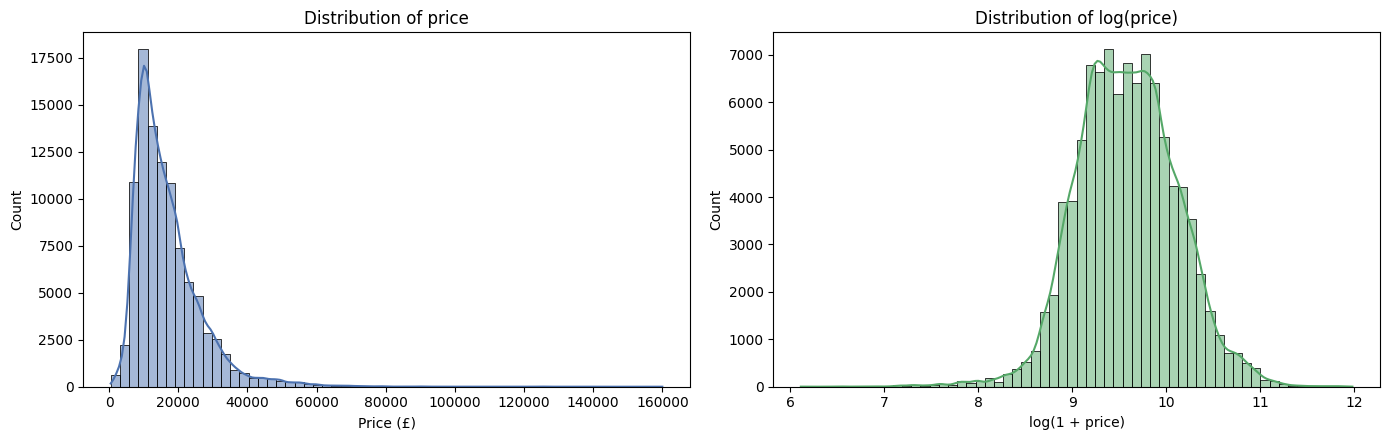

Skewness of price: 2.36  |  skewness of log(price): -0.08


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(df["price"], bins=60, kde=True, color="#4C72B0", ax=axes[0])
axes[0].set_title("Distribution of price")
axes[0].set_xlabel("Price (£)")
sns.histplot(np.log1p(df["price"]), bins=60, kde=True, color="#55A868", ax=axes[1])
axes[1].set_title("Distribution of log(price)")
axes[1].set_xlabel("log(1 + price)")
plt.tight_layout()
plt.show()
print(f"Skewness of price: {df['price'].skew():.2f}  |  skewness of log(price): {np.log1p(df['price']).skew():.2f}")

**Conclusion:** price is strongly **right-skewed** (skewness ≈ 2.4): most cars cost £8,000–£25,000 and a small number of luxury cars reach £100,000+. After a log transform the shape is almost symmetric (skewness ≈ −0.08).
This means errors in £ will naturally be larger for expensive cars. Tree-based models do not need the target to be normal, so we keep `price` in £ and read errors in £.

### 4.2 Price vs Mileage

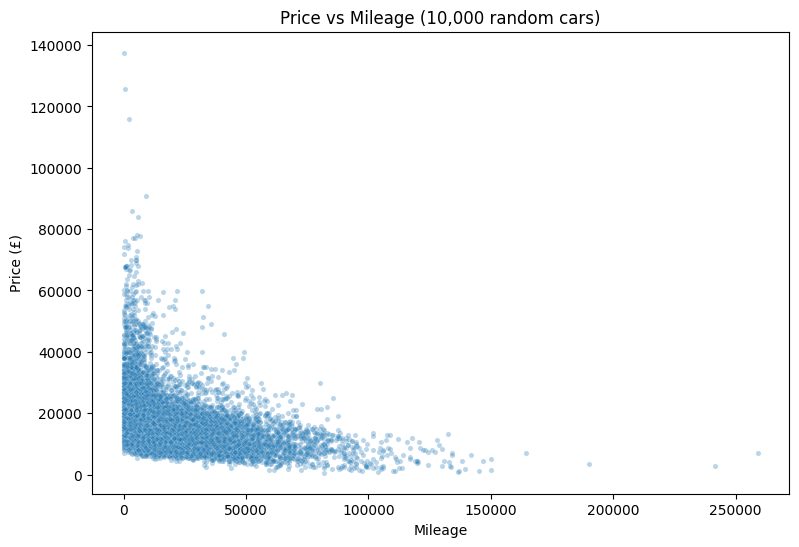

In [ ]:
sample = df.sample(10000, random_state=RANDOM_STATE)   # sample so the plot stays readable
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=sample, x="mileage", y="price", alpha=0.3, s=14, ax=ax)
ax.set_title("Price vs Mileage (10,000 random cars)")
ax.set_xlabel("Mileage")
ax.set_ylabel("Price (£)")
plt.show()

**Conclusion:** more mileage generally means a lower price, but the relationship is **not a clean line**: at any mileage there is a huge spread of prices (a 40,000-mile Ford costs far less than a 40,000-mile Mercedes).
Mileage alone does not determine price — it has to be combined with age, make and engine. The curve also flattens at high mileage.

### 4.3 Price vs Year

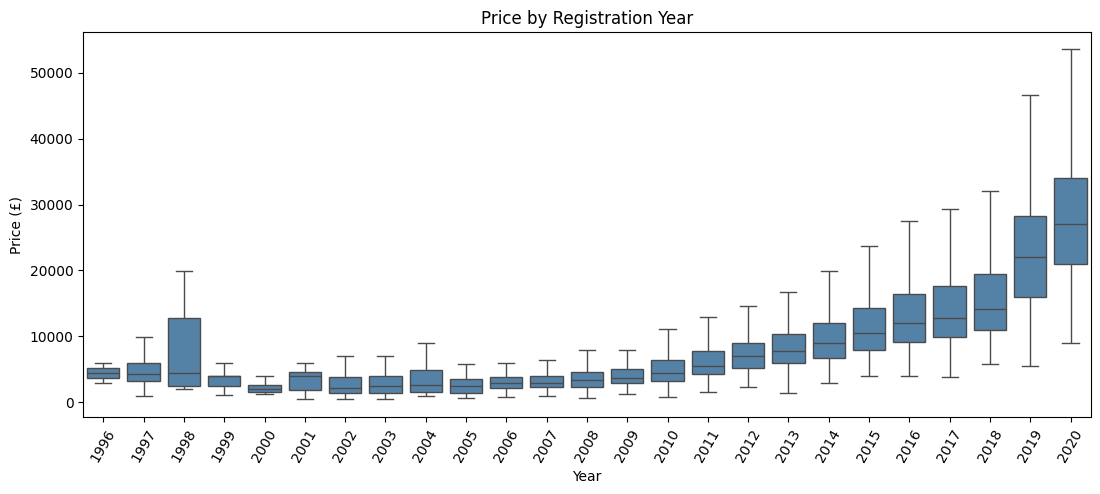

Median price by year:
year
2005     2495.0
2010     4497.0
2015    10490.0
2017    12800.0
2019    21990.0
2020    26990.0


In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df, x="year", y="price", showfliers=False, color="steelblue", ax=ax)
ax.set_title("Price by Registration Year")
ax.set_xlabel("Year")
ax.set_ylabel("Price (£)")
plt.xticks(rotation=60)
plt.show()

print("Median price by year:")
print(df.groupby("year")["price"].median().loc[[2005, 2010, 2015, 2017, 2019, 2020]].round(0).to_string())

**Conclusion:** price rises steadily with the registration year, and **the increase accelerates** for the newest cars — a median of about £4,500 for 2010 cars, £10,500 for 2015 cars and £27,000 for 2020 cars.
This is classic depreciation and a **non-linear** relationship, which is a strong reason to expect tree-based models to beat plain linear regression. It also motivates the `car_age` feature in Section 6.

### 4.4 Average price by manufacturer

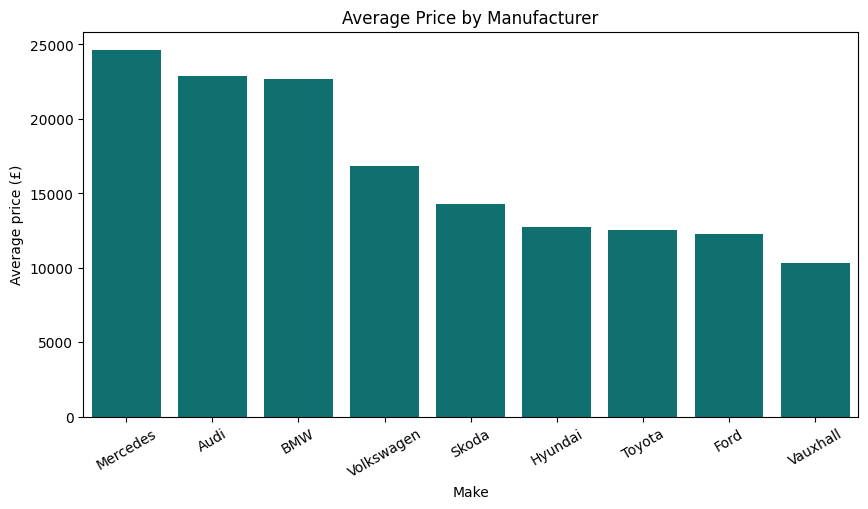

Make
Mercedes      24636.0
Audi          22854.0
BMW           22693.0
Volkswagen    16808.0
Skoda         14285.0
Hyundai       12728.0
Toyota        12530.0
Ford          12270.0
Vauxhall      10314.0


In [ ]:
order = df.groupby("Make")["price"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=order.index, y=order.values, color="teal", ax=ax)
ax.set_title("Average Price by Manufacturer")
ax.set_ylabel("Average price (£)")
plt.xticks(rotation=30)
plt.show()
print(order.round(0).to_string())

**Conclusion:** the three German premium brands (**Mercedes ≈ £24,600, Audi ≈ £22,900, BMW ≈ £22,700**) are clearly more expensive than the rest. Volkswagen sits in the middle (≈ £16,800) and Vauxhall (≈ £10,300) is the cheapest.
Brand is a major price driver — a strong reason to keep `Make` and to create the `is_premium_brand` feature.

### 4.5 Price by transmission and fuel type

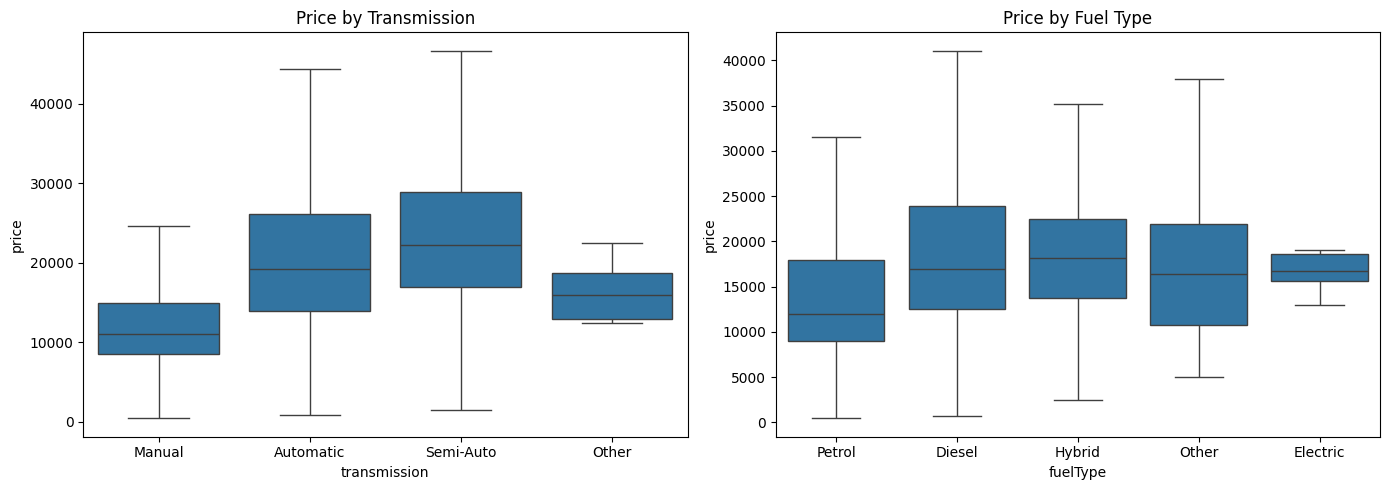

{'Automatic': 19245.0, 'Manual': 11000.0, 'Other': 15999.0, 'Semi-Auto': 22250.0}
{'Diesel': 17000.0, 'Electric': 16688.0, 'Hybrid': 18200.0, 'Other': 16450.0, 'Petrol': 11998.0}


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="transmission", y="price", showfliers=False, ax=axes[0])
axes[0].set_title("Price by Transmission")
sns.boxplot(data=df, x="fuelType", y="price", showfliers=False, ax=axes[1])
axes[1].set_title("Price by Fuel Type")
plt.tight_layout()
plt.show()

print(df.groupby("transmission")["price"].median().round(0).to_dict())
print(df.groupby("fuelType")["price"].median().round(0).to_dict())

**Conclusion:** Semi-Auto (median ≈ £22,250) and Automatic (≈ £19,250) cars cost much more than Manual (≈ £11,000). For fuel, Hybrid (≈ £18,200) and Diesel (≈ £17,000) are priced above Petrol (≈ £12,000) —
partly because diesels are often larger / premium cars and hybrids are newer technology. Both columns are useful predictors.

### 4.6 Correlation heatmap

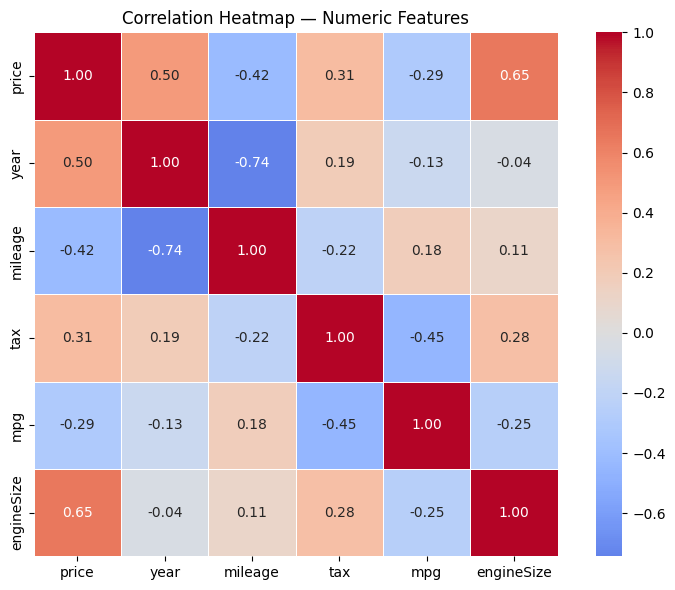

In [ ]:
corr = df[["price", "year", "mileage", "tax", "mpg", "engineSize"]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

**Conclusion:** the strongest linear relationships with price are **engineSize (+0.65)**, **year (+0.50)**, **mileage (−0.42)**, **tax (+0.31)** and **mpg (−0.29)**. `year` and `mileage` are also correlated with each other (≈ −0.74): newer cars have fewer miles.
A correlation heatmap only captures *straight-line* numeric relationships and says nothing about make, model, transmission or fuel type, which we know matter a lot — that is why we need a full model.

---
# 5. Train / Validation / Test Split (70 / 15 / 15)

We split **before** any preprocessing is fitted, to avoid data leakage:

- **Training set (70%)** — the models learn from it.
- **Validation set (15%)** — used to compare models and tune hyperparameters.
- **Test set (15%)** — **untouched** until the final model is chosen, then used exactly once.

Two steps: 70% / 30%, then the 30% is divided in half.

In [ ]:
X = df.drop(columns=["price"])
y = df["price"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE)

print(f"Training set  : {len(X_train):,} cars ({len(X_train) / len(df):.0%})")
print(f"Validation set: {len(X_val):,} cars ({len(X_val) / len(df):.0%})")
print(f"Test set      : {len(X_test):,} cars ({len(X_test) / len(df):.0%})")
print(f"\nMean price  train: £{y_train.mean():,.0f} | val: £{y_val.mean():,.0f} | test: £{y_test.mean():,.0f}")

Training set  : 68,396 cars (70%)
Validation set: 14,656 cars (15%)
Test set      : 14,657 cars (15%)

Mean price  train: £16,792 | val: £16,760 | test: £16,699


**Check:** the three sets have almost the same mean price, so the random split is representative. (We do not use `stratify`: that is for classification classes, and our target is a continuous number.)

---
# 6. Feature Engineering

New features can give the model information that is hard to extract from the raw columns. We create **4 features**, using a fixed **reference year of 2020**: the data was scraped in 2020 and the newest cars in it are from 2020.

| Feature | Formula | Why it should help predict price |
|---|---|---|
| `car_age` | 2020 − `year` | Age is the main driver of depreciation, and “age in years” is easier for a model to use than a calendar year. |
| `mileage_per_year` | `mileage` / max(`car_age`, 1) | **Usage intensity.** 60,000 miles on a 3-year-old car (heavy use) means something very different from 60,000 miles on a 10-year-old car (light use). Cars of age 0 would divide by zero, so their age is treated as 1. |
| `is_premium_brand` | 1 if Audi / BMW / Mercedes, else 0 | EDA (4.4) showed the premium brands are far more expensive. This gives the model a simple brand-level signal. |
| `is_zero_tax` | 1 if `tax` = £0, else 0 | Zero road tax flags low-emission / eco cars, which are priced differently. |

These formulas use **no statistics learned from the data**, so applying them to all three splits cannot leak information.

In [ ]:
REFERENCE_YEAR = 2020

def add_features(data):
    out = data.copy()
    out["car_age"] = (REFERENCE_YEAR - out["year"]).clip(lower=0)
    out["mileage_per_year"] = out["mileage"] / out["car_age"].clip(lower=1)      # safe when car_age = 0
    out["is_premium_brand"] = out["Make"].isin(["Audi", "BMW", "Mercedes"]).astype(int)
    out["is_zero_tax"] = (out["tax"] == 0).astype(int)
    return out

X_train = add_features(X_train)
X_val   = add_features(X_val)
X_test  = add_features(X_test)

X_train[["year", "car_age", "mileage", "mileage_per_year", "Make", "is_premium_brand", "tax", "is_zero_tax"]].head()

,year,car_age,mileage,mileage_per_year,Make,is_premium_brand,tax,is_zero_tax
33060,2019,1,4694,4694.0,Ford,0,145,0
39881,2018,2,10052,5026.0,Hyundai,0,135,0
42670,2017,3,11247,3749.0,Hyundai,0,135,0
64942,2017,3,16845,5615.0,Toyota,0,145,0
48053,2019,1,5662,5662.0,Mercedes,1,145,0


In [ ]:
# do the new features carry information about price? (training data only)
check = X_train.assign(price=y_train)
print(check[["car_age", "mileage_per_year", "is_premium_brand", "is_zero_tax", "price"]].corr()["price"].drop("price").round(3).to_string())

car_age            -0.496
mileage_per_year   -0.192
is_premium_brand    0.498
is_zero_tax        -0.179


**Interpretation:** `car_age` correlates with price as strongly as `year` does (opposite sign, since it is just 2020 − `year`): it carries the same information in a more convenient form.
`mileage_per_year` adds something different — how *hard* a car was used. Whether the final model actually uses these features is checked in Section 13.

---
# 7. Data Preprocessing

All preprocessing is **fitted on the training set only**, then applied (with `transform`) to the validation and test sets.

### 7.1 Numerical vs categorical features

In [ ]:
num_features = ["year", "mileage", "tax", "mpg", "engineSize",
                "car_age", "mileage_per_year", "is_premium_brand", "is_zero_tax"]
cat_features = ["Make", "model", "transmission", "fuelType"]

print("Numerical features  :", num_features)
print("Categorical features:", cat_features)
print("\nMissing values in the training set:")
print(X_train[num_features + cat_features].isnull().sum()[lambda s: s > 0].to_string())

Numerical features  : ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'car_age', 'mileage_per_year', 'is_premium_brand', 'is_zero_tax']
Categorical features: ['Make', 'model', 'transmission', 'fuelType']

Missing values in the training set:
mpg            26
engineSize    158


### 7.2 What each step does

- **Imputation (`SimpleImputer`, median)** — fills the `NaN`s created in Section 3 (`engineSize`, `mpg`). The median is robust to extreme values (important for `mpg`, which has extreme hybrid values) and is **learned from the training set only**.
- **Scaling (`StandardScaler`)** — puts numeric features on the same scale (mean 0, std 1). Linear regression needs it because `mileage` is in the tens of thousands while `engineSize` is around 1–2; tree-based models do not need it but are not harmed, so one scaled version is used for all models.
- **One-Hot Encoding** — turns each category (`Make`, `model`, `transmission`, `fuelType`) into 0/1 columns without inventing a fake order (a label encoding would imply Audi > Ford). `handle_unknown="ignore"` keeps the encoder safe if validation / test contain a category never seen in training.

In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
])

# fit_transform on TRAINING data only: learns medians, means/stds and the category lists
X_train_prep = preprocessor.fit_transform(X_train)
# transform only on validation / test: re-uses what was learned from the training data
X_val_prep  = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_prep = pd.DataFrame(X_train_prep, columns=feature_names, index=X_train.index)
X_val_prep   = pd.DataFrame(X_val_prep,   columns=feature_names, index=X_val.index)
X_test_prep  = pd.DataFrame(X_test_prep,  columns=feature_names, index=X_test.index)

print("Shape before preprocessing:", X_train.shape)
print("Shape after preprocessing :", X_train_prep.shape, "<- one-hot encoding created many 0/1 columns")
print("Missing values left (train / val / test):",
      X_train_prep.isnull().sum().sum(), X_val_prep.isnull().sum().sum(), X_test_prep.isnull().sum().sum())

Shape before preprocessing: (68396, 13)
Shape after preprocessing : (68396, 218) <- one-hot encoding created many 0/1 columns
Missing values left (train / val / test): 0 0 0


### 7.3 Proof that there is no leakage

In [ ]:
demo = ["num__mileage", "num__engineSize", "num__car_age"]
print("TRAINING set (mean ≈ 0, std ≈ 1 by construction):")
print(X_train_prep[demo].describe().loc[["mean", "std"]].round(3).to_string())
print("\nVALIDATION set (close to, but NOT exactly, 0 and 1 — it used the training statistics):")
print(X_val_prep[demo].describe().loc[["mean", "std"]].round(3).to_string())

TRAINING set (mean ≈ 0, std ≈ 1 by construction):
      num__mileage  num__engineSize  num__car_age
mean           0.0             -0.0           0.0
std            1.0              1.0           1.0

VALIDATION set (close to, but NOT exactly, 0 and 1 — it used the training statistics):
      num__mileage  num__engineSize  num__car_age
mean         0.003           -0.002         0.004
std          1.009            1.002         1.011


**Interpretation:** on the training set every scaled feature has mean 0 and std 1. On the validation set the values are *close but not identical* — exactly what we want: it shows the scaler used the **training** statistics instead of re-learning them from the validation data.

---
# 8. Train the Regression Models

We train **5 regression models**, each representing a different idea, using the same recipe: **instantiate → fit on the training set → predict on the validation set → evaluate**.

| Model | Idea | Expectation |
|---|---|---|
| Linear Regression | one straight-line (hyperplane) equation | baseline; depreciation is curved, so it should underfit |
| Decision Tree | yes/no questions that split the cars into groups | captures non-linearity and interactions, but can overfit |
| Random Forest | average of many trees trained on random samples (bagging) | much more stable than one tree |
| Gradient Boosting | trees built one after another, each correcting the previous errors | strong on tabular data |
| XGBoost | optimised, regularised gradient boosting | usually the best on tabular data |

Metrics (always on the **validation** set):
- **R²** — share of price variation explained (1.0 = perfect, 0 = no better than predicting the average price)
- **MAE** — average absolute error in £ (“on average we are £X off”)
- **RMSE** — like MAE, but squares the errors first, so **large mistakes are punished more**

We also store the training R² (on a fixed random sample of 10,000 training cars, to keep it fast) for the overfitting check in Section 10.

In [ ]:
results, train_r2, trained = {}, {}, {}

# fixed 10,000-car sample of the training set, used only to compute the training R²
rng = np.random.RandomState(RANDOM_STATE)
sub_idx = rng.choice(len(X_train_prep), size=10000, replace=False)
X_train_sub, y_train_sub = X_train_prep.iloc[sub_idx], y_train.iloc[sub_idx]

def evaluate_regressor(name, model):
    """Store validation R2 / MAE / RMSE and the training R2 of an already trained model."""
    pred = model.predict(X_val_prep)
    results[name] = {
        "R2": r2_score(y_val, pred),
        "MAE": mean_absolute_error(y_val, pred),
        "RMSE": np.sqrt(mean_squared_error(y_val, pred)),
    }
    train_r2[name] = r2_score(y_train_sub, model.predict(X_train_sub))
    trained[name] = model
    print(f"{name:<18} R2 = {results[name]['R2']:.4f} (train {train_r2[name]:.4f}) | "
          f"MAE = £{results[name]['MAE']:,.0f} | RMSE = £{results[name]['RMSE']:,.0f}")

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=12, min_samples_leaf=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_features=0.33, min_samples_leaf=3,
                                           n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, max_depth=5, learning_rate=0.1,
                                                   subsample=0.8, random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.1, subsample=0.8,
                            colsample_bytree=0.8, tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE),
}

for name, model in models.items():
    model.fit(X_train_prep, y_train)
    evaluate_regressor(name, model)

Linear Regression  R2 = 0.8652 (train 0.8801) | MAE = £2,264 | RMSE = £3,638
Decision Tree      R2 = 0.9264 (train 0.9418) | MAE = £1,715 | RMSE = £2,688
Random Forest      R2 = 0.9549 (train 0.9768) | MAE = £1,189 | RMSE = £2,104
Gradient Boosting  R2 = 0.9392 (train 0.9472) | MAE = £1,574 | RMSE = £2,443
XGBoost            R2 = 0.9574 (train 0.9702) | MAE = £1,252 | RMSE = £2,046


---
# 9. Evaluate & Compare the Models (validation set)

Higher R² and lower MAE / RMSE are better.

In [ ]:
results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df.index.name = "Model"
(results_df.style
    .background_gradient(cmap="Greens_r", subset=["MAE", "RMSE"])
    .background_gradient(cmap="Greens", subset=["R2"])
    .format({"R2": "{:.4f}", "MAE": "£{:,.0f}", "RMSE": "£{:,.0f}"}))

,R2,MAE,RMSE
Model,,,
XGBoost,0.9574,"£1,252","£2,046"
Random Forest,0.9549,"£1,189","£2,104"
Gradient Boosting,0.9392,"£1,574","£2,443"
Decision Tree,0.9264,"£1,715","£2,688"
Linear Regression,0.8652,"£2,264","£3,638"


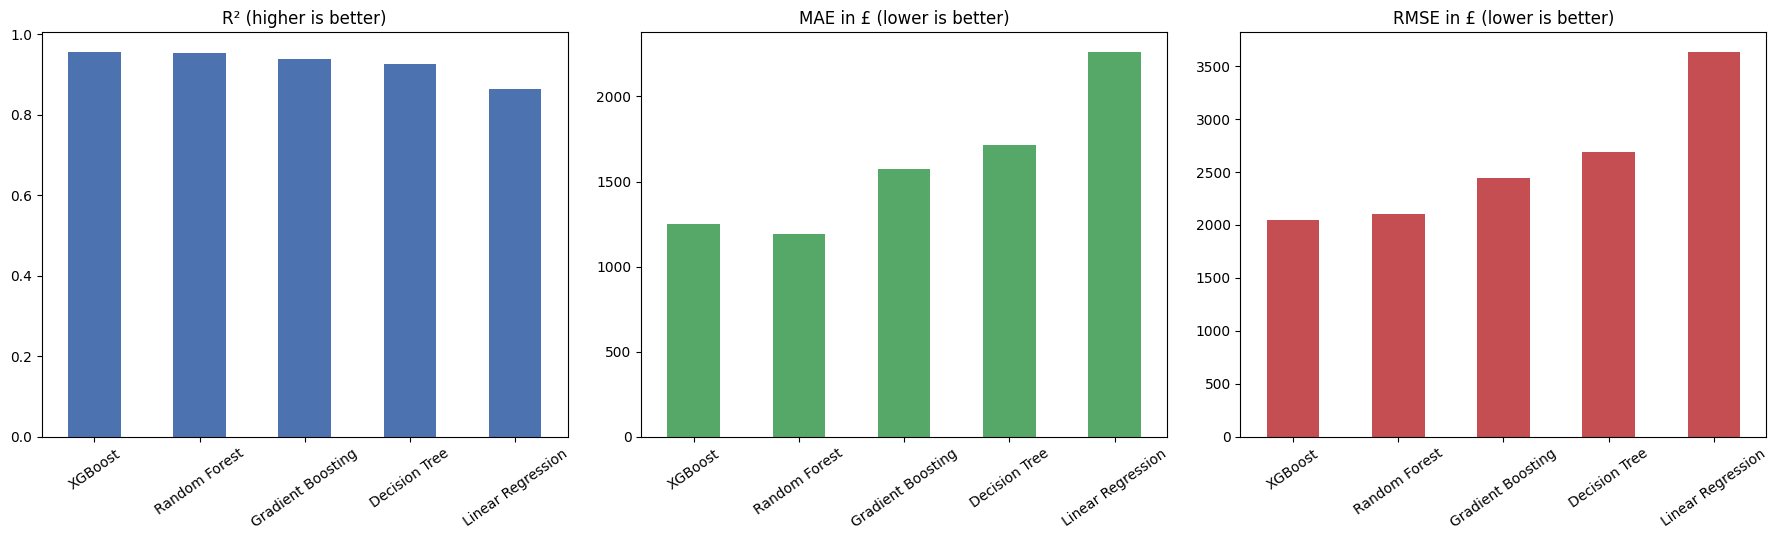

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (metric, color, title) in zip(axes, [("R2", "#4C72B0", "R² (higher is better)"),
                                             ("MAE", "#55A868", "MAE in £ (lower is better)"),
                                             ("RMSE", "#C44E52", "RMSE in £ (lower is better)")]):
    results_df[metric].plot(kind="bar", ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

**Discussion** (numbers from our run):

| Model | R² | MAE | RMSE |
|---|---|---|---|
| XGBoost | 0.957 | £1,252 | £2,046 |
| Random Forest | 0.955 | £1,189 | £2,104 |
| Gradient Boosting | 0.939 | £1,574 | £2,443 |
| Decision Tree | 0.926 | £1,715 | £2,688 |
| Linear Regression | 0.865 | £2,264 | £3,638 |

- **XGBoost and Random Forest are the best models** and are very close. Random Forest has a slightly lower MAE, but XGBoost has the lowest RMSE, so it makes fewer *very large* mistakes (mostly on expensive cars).
- **Gradient Boosting and the Decision Tree** are in the middle: a single tree already beats Linear Regression, which shows how much non-linearity matters. scikit-learn's Gradient Boosting (150 trees, untuned) is clearly behind XGBoost.
- **Linear Regression is the weakest**: it cannot represent the curved depreciation and the interactions between age, brand and engine size that Section 4 revealed.
- Every model except Linear Regression already passes the project's R² > 0.90 target.

---
# 10. Check for Overfitting

A model that scores much better on the data it trained on than on new data has **memorised noise instead of learning the pattern**. We compare each model's training R² with its validation R²: a **small gap** suggests good generalisation, a **large gap** suggests overfitting.

,Train R2,Validation R2,Gap (train - val)
Random Forest,0.9768,0.9549,0.0219
Decision Tree,0.9418,0.9264,0.0154
Linear Regression,0.8801,0.8652,0.0149
XGBoost,0.9702,0.9574,0.0129
Gradient Boosting,0.9472,0.9392,0.0080


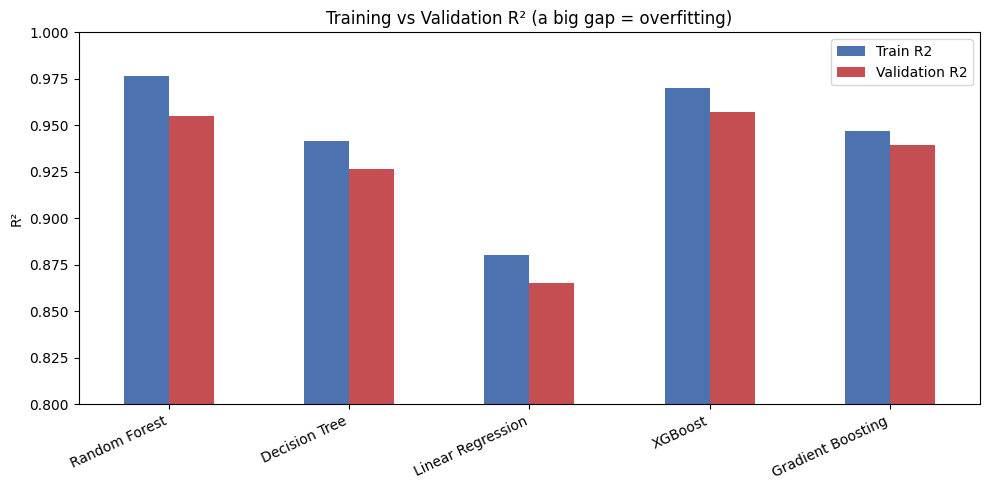

In [ ]:
overfit = pd.DataFrame({"Train R2": pd.Series(train_r2), "Validation R2": results_df["R2"]})
overfit["Gap (train - val)"] = overfit["Train R2"] - overfit["Validation R2"]
overfit = overfit.sort_values("Gap (train - val)", ascending=False)
display(overfit.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
overfit[["Train R2", "Validation R2"]].plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title("Training vs Validation R² (a big gap = overfitting)")
ax.set_ylabel("R²")
ax.set_ylim(0.8, 1.0)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

**Interpretation:**

| Model | Train R² | Validation R² | Gap |
|---|---|---|---|
| Random Forest | 0.977 | 0.955 | 0.022 |
| Decision Tree | 0.942 | 0.926 | 0.015 |
| Linear Regression | 0.880 | 0.865 | 0.015 |
| XGBoost | 0.970 | 0.957 | 0.013 |
| Gradient Boosting | 0.947 | 0.939 | 0.008 |

- **No model is badly overfitted**: all gaps are small (≤ 0.022).
- **Linear Regression** has a small gap but a *low* score on both sets — it **underfits** (the model is too simple), which is the opposite problem.
- **Random Forest** has the largest gap (≈ 0.02): it fits the training cars very closely and loses a little on new ones.
- **XGBoost** combines the highest validation R² with a small gap — the best balance so far. Gradient Boosting has the smallest gap but a lower score.

---
# 11. Improve the Best Model (Hyperparameter Tuning)

Hyperparameters are settings chosen *before* training (number of trees, depth, learning rate). We tune the strongest model with **`GridSearchCV`**: it tries **every combination** in a grid and scores each one with **3-fold cross-validation** (the training data is split in 3 parts; the model trains on 2 and is scored on the 3rd, rotating).
The validation set is then used to check whether tuning really helped.

> Simplification: the cross-validation runs on the already-preprocessed training data; no validation or test rows are involved.

In [ ]:
best_before = results_df["RMSE"].idxmin()
print("Best model before tuning (lowest validation RMSE):", best_before)

Best model before tuning (lowest validation RMSE): XGBoost


In [ ]:
param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [6, 8],
    "learning_rate": [0.05, 0.1],
}

grid = GridSearchCV(
    XGBRegressor(subsample=0.8, colsample_bytree=0.8, tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE),
    param_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=1, verbose=1)
grid.fit(X_train_prep, y_train)

print("Best parameters:", grid.best_params_)
print(f"Best cross-validated RMSE: £{-grid.best_score_:,.0f}")

cv_table = pd.DataFrame(grid.cv_results_)[["param_n_estimators", "param_max_depth", "param_learning_rate", "mean_test_score"]]
cv_table["CV RMSE (£)"] = (-cv_table["mean_test_score"]).round(0)
cv_table = cv_table.drop(columns="mean_test_score").sort_values("CV RMSE (£)")
cv_table.columns = ["n_estimators", "max_depth", "learning_rate", "CV RMSE (£)"]
display(cv_table.reset_index(drop=True))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 600}
Best cross-validated RMSE: £1,918


,n_estimators,max_depth,learning_rate,CV RMSE (£)
0,600,8,0.10,1918.0
1,600,8,0.05,1959.0
2,600,6,0.10,1960.0
3,300,8,0.10,1967.0
4,300,8,0.05,2053.0
5,600,6,0.05,2081.0
6,300,6,0.10,2086.0
7,300,6,0.05,2255.0


In [ ]:
xgb_tuned = grid.best_estimator_
evaluate_regressor("XGBoost (tuned)", xgb_tuned)

before_after = pd.DataFrame({"Before tuning": results["XGBoost"], "After tuning": results["XGBoost (tuned)"]}).T
before_after["Train R2"] = [train_r2["XGBoost"], train_r2["XGBoost (tuned)"]]
before_after.style.format({"R2": "{:.4f}", "MAE": "£{:,.0f}", "RMSE": "£{:,.0f}", "Train R2": "{:.4f}"})

XGBoost (tuned)    R2 = 0.9627 (train 0.9846) | MAE = £1,105 | RMSE = £1,914


,R2,MAE,RMSE,Train R2
Before tuning,0.9574,"£1,252","£2,046",0.9702
After tuning,0.9627,"£1,105","£1,914",0.9846


**Before → After tuning** (our run):

| | R² | MAE | RMSE |
|---|---|---|---|
| Before tuning | 0.9574 | £1,252 | £2,046 |
| After tuning | 0.9627 | £1,105 | £1,914 |

**Did tuning help?** Yes, modestly but clearly: R² rose by about 0.005, MAE dropped by ≈ £150 (12%) and RMSE by ≈ £130 (6%). The grid search chose the **bigger, deeper** model (600 trees, depth 8, learning rate 0.1) — the best CV scores are all at the edge of the grid, so even bigger models might help a little more.

There is a trade-off: the training-vs-validation gap grew from ≈ 0.013 to ≈ 0.022 (the deeper model fits the training data more tightly), and the search needed 24 model fits instead of 1. Most of the accuracy came from choosing the right *type* of model; tuning only polished it.

---
# 12. Select the Final Model & Evaluate on the Test Set

The final model is chosen with **validation** information only: R², MAE, RMSE and the overfitting gap. The test set is not used for choosing.

In [ ]:
final_table = pd.DataFrame(results).T
final_table["Train R2 - Val R2"] = [train_r2[n] - results[n]["R2"] for n in final_table.index]
final_table = final_table.sort_values("RMSE")
display(final_table.round(4))

final_name = final_table["RMSE"].idxmin()
final_model = trained[final_name]
print("Final model selected:", final_name)

,R2,MAE,RMSE,Train R2 - Val R2
XGBoost (tuned),0.9627,1104.9552,1914.2322,0.0220
XGBoost,0.9574,1252.0845,2046.2296,0.0129
Random Forest,0.9549,1189.0606,2103.8144,0.0219
Gradient Boosting,0.9392,1574.0519,2443.3123,0.0080
Decision Tree,0.9264,1714.7034,2688.1481,0.0154
Linear Regression,0.8652,2263.9735,3638.1010,0.0149


Final model selected: XGBoost (tuned)


**Why this model?** The tuned XGBoost has the **highest R²**, the **lowest MAE** and the **lowest RMSE** on the validation set. Its overfitting gap (≈ 0.022) is the same as Random Forest's and still small, so it is not paying for its accuracy with poor generalisation. It is also fast at prediction time and keeps no training data in memory, which suits the Streamlit app.

### Evaluating the final model on the untouched test set — once

In [ ]:
y_test_pred = final_model.predict(X_test_prep)

test_r2   = r2_score(y_test, y_test_pred)
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"FINAL TEST RESULTS — {final_name}")
print(f"R²  : {test_r2:.4f}")
print(f"MAE : £{test_mae:,.0f}")
print(f"RMSE: £{test_rmse:,.0f}")

pd.DataFrame({"Validation": results[final_name],
              "Test": {"R2": test_r2, "MAE": test_mae, "RMSE": test_rmse}}).T.style.format(
    {"R2": "{:.4f}", "MAE": "£{:,.0f}", "RMSE": "£{:,.0f}"})

FINAL TEST RESULTS — XGBoost (tuned)
R²  : 0.9677
MAE : £1,106
RMSE: £1,778


,R2,MAE,RMSE
Validation,0.9627,"£1,105","£1,914"
Test,0.9677,"£1,106","£1,778"


**Final test results** (our run): **R² = 0.9677, MAE = £1,106, RMSE = £1,778.**

The test score is very close to the validation score (R² 0.9627), so the model did not just get lucky on the validation data — it generalises, and our process (split first, fit preprocessing on training only, test set used once) avoided leakage. It clears the project target of R² > 0.90 comfortably.
In plain English: for a typical car the estimate is within about **£1,100 of the real asking price**, and about 97% of the variation in prices is explained.

---
# 13. Understand the Model

A good score is not enough: we want to know *how* the model predicts and *where* it fails.

### 13.1 Actual vs Predicted price

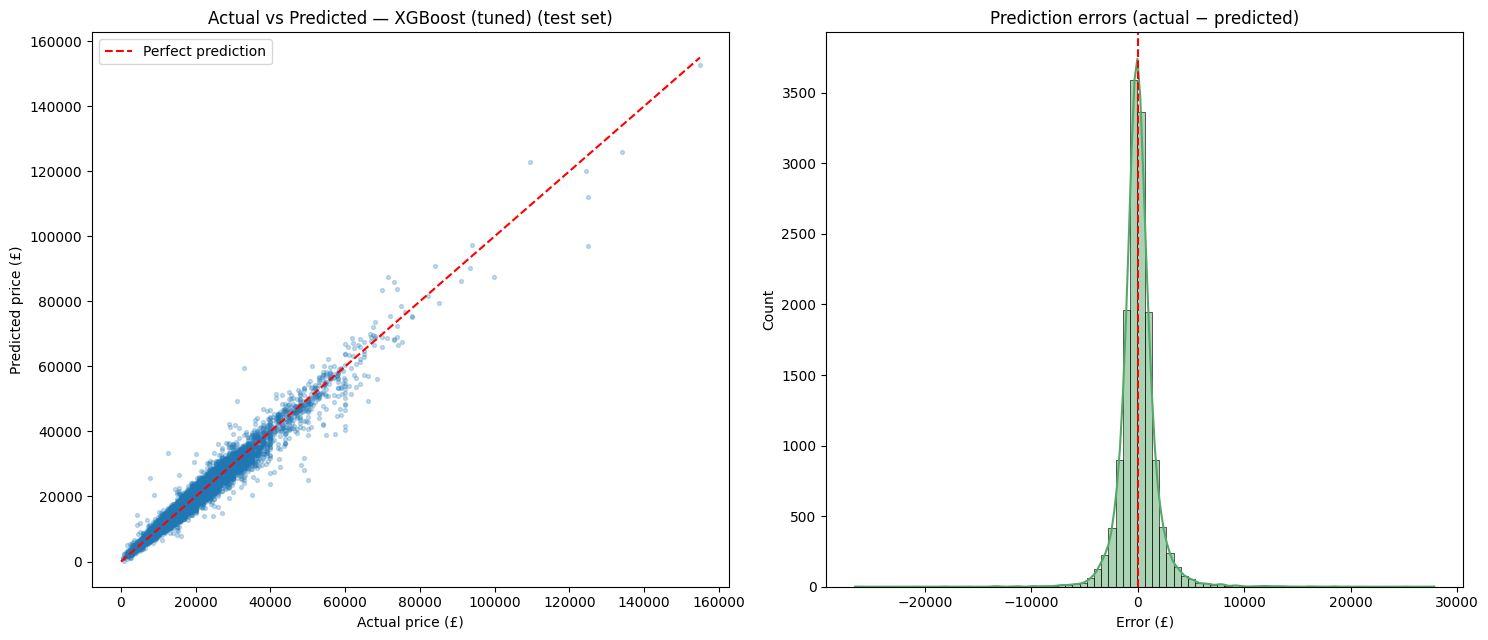

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

axes[0].scatter(y_test, y_test_pred, alpha=0.25, s=8)
lim = [0, max(y_test.max(), y_test_pred.max())]
axes[0].plot(lim, lim, "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual price (£)")
axes[0].set_ylabel("Predicted price (£)")
axes[0].set_title(f"Actual vs Predicted — {final_name} (test set)")
axes[0].legend()

residuals = y_test - y_test_pred
sns.histplot(residuals, bins=80, kde=True, ax=axes[1], color="#55A868")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Prediction errors (actual − predicted)")
axes[1].set_xlabel("Error (£)")
plt.tight_layout()
plt.show()

**Conclusion:** the points hug the red “perfect prediction” line across the whole price range, and the error histogram is centred near zero, so the model has no strong bias towards over- or under-pricing.
The scatter widens for expensive cars (above ≈ £40,000) — expected, because there are far fewer of them to learn from and each is more unique (trim, rarity, options).

### 13.2 Feature importance

For tree models, `feature_importances_` shows how much each feature helped reduce the prediction error. One-hot encoding splits each categorical feature into many columns (`Make_BMW`, `Make_Ford`, …), so we also **add those columns back together** to see the importance of each *original* feature.

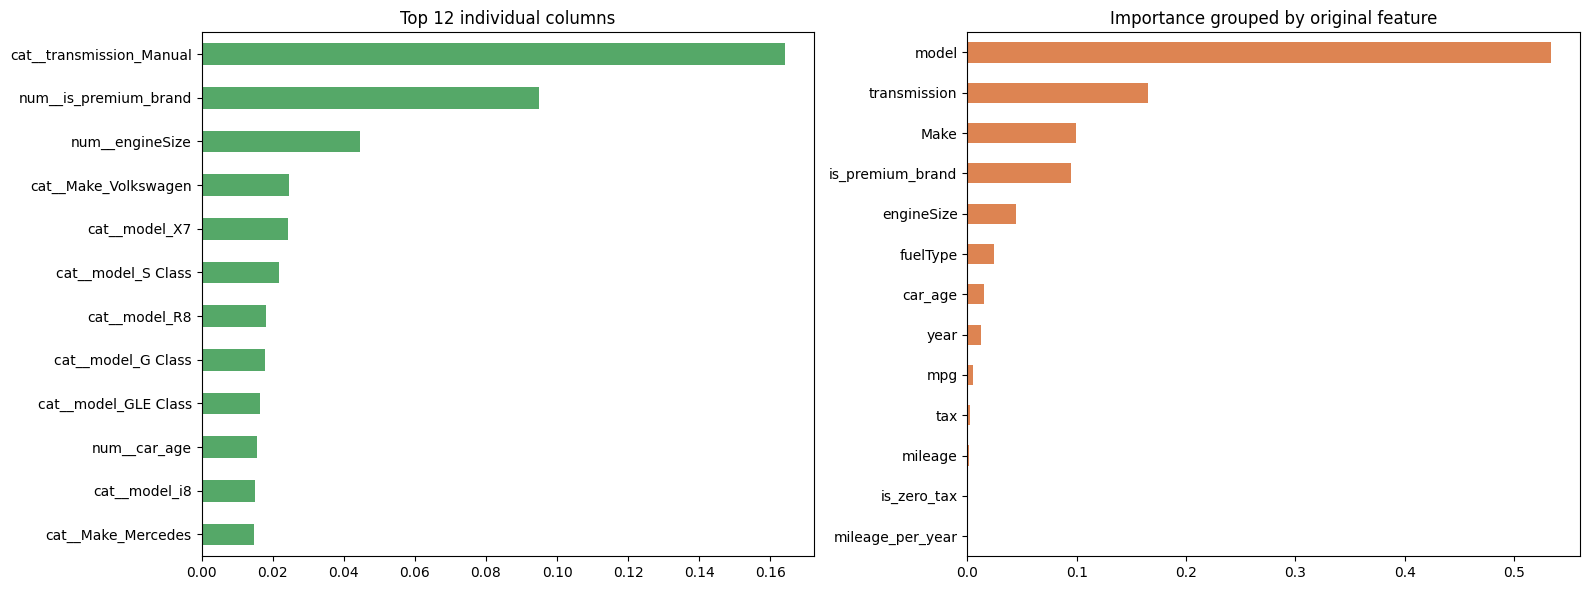

,importance
model,0.5337
transmission,0.1650
Make,0.0992
is_premium_brand,0.0951
engineSize,0.0446
fuelType,0.0239
car_age,0.0155
year,0.0129
mpg,0.0051
tax,0.0025


In [ ]:
if hasattr(final_model, "feature_importances_"):          # tree models
    importance = pd.Series(final_model.feature_importances_, index=X_train_prep.columns)
else:                                                     # linear model: size of the coefficients
    importance = pd.Series(np.abs(final_model.coef_), index=X_train_prep.columns)
importance = importance.sort_values(ascending=False)

def original_feature(col):
    col = col.split("__", 1)[1]
    for c in cat_features:
        if col.startswith(c + "_"):
            return c
    return col

grouped = importance.groupby([original_feature(c) for c in importance.index]).sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
importance.head(12).sort_values().plot(kind="barh", ax=axes[0], color="#55A868")
axes[0].set_title("Top 12 individual columns")
grouped.sort_values().plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Importance grouped by original feature")
plt.tight_layout()
plt.show()
grouped.round(4).to_frame("importance")

**Interpretation** (grouped importance of the final model, our run):

| Feature | Importance |
|---|---|
| `model` | 53.4% |
| `transmission` | 16.5% |
| `Make` | 9.9% |
| `is_premium_brand` | 9.5% |
| `engineSize` | 4.5% |
| `fuelType` | 2.4% |
| `car_age` + `year` | 2.8% |
| `mpg`, `tax`, `mileage` | 0.5%, 0.3%, 0.2% |
| `is_zero_tax`, `mileage_per_year` | ≈ 0.04% each |

- **Which car it is matters most.** `model` (a Golf vs a G-Class) together with `Make` and `is_premium_brand` carries ≈ 73% of the importance. Part of `model`'s large share is because it is split into ~190 one-hot columns that we add back together.
- **Transmission** is the second most important feature (mostly manual vs automatic / semi-auto), and **engine size** also matters; both partly act as a proxy for the car's class.
- **Age** is used, but its share is small *because* `car_age` and `year` are the same information and share the importance. EDA showed age is a strong price driver (median £4,500 for 2010 cars vs £27,000 for 2020).
- **Mileage has a low importance** even though its correlation with price is −0.42: once the model knows the car's model, age and engine, extra miles add little. Mileage is correlated with age (−0.74), so age “takes” most of its credit.
- **Engineered features:** `is_premium_brand` is useful, `car_age` duplicates `year`, and `mileage_per_year` and `is_zero_tax` add almost nothing. Not every engineered feature helps — and that is a finding worth reporting.

*Caution:* importance values of correlated features are shared between them, so they show what the model relies on, not a causal effect on price.

### 13.3 Where does the model make large errors?

In [ ]:
err = X_test[["Make", "model", "year", "mileage", "transmission", "fuelType", "engineSize"]].copy()
err["actual"] = y_test.values
err["predicted"] = y_test_pred.round(0)
err["error"] = err["predicted"] - err["actual"]
err["abs_pct_error"] = (err["error"].abs() / err["actual"] * 100).round(1)

print("Top 12 largest absolute errors:")
display(err.reindex(err["error"].abs().sort_values(ascending=False).index).head(12))

print("Error by manufacturer:")
by_make = err.groupby("Make").agg(MAE=("error", lambda s: s.abs().mean()),
                                  MedianAPE=("abs_pct_error", "median")).round(1)
display(by_make.sort_values("MAE"))

print("Median % error by price band:")
err["price_band"] = pd.cut(err["actual"], [0, 8000, 15000, 25000, 40000, 200000])
display(err.groupby("price_band", observed=True)["abs_pct_error"].median().round(1).to_frame("median % error"))

Top 12 largest absolute errors:


,Make,model,year,mileage,transmission,fuelType,engineSize,actual,predicted,error,abs_pct_error
3342,Audi,R8,2019,100,Automatic,Petrol,5.2,125000,97154.0,-27846.0,22.3
28366,Ford,Mustang,2017,12000,Automatic,Petrol,5.0,32990,59562.0,26572.0,80.5
33011,Ford,Mustang,2017,21575,Manual,Petrol,5.0,49999,24951.0,-25048.0,50.1
700,Audi,Q7,2016,26705,Semi-Auto,Diesel,3.0,12500,33446.0,20946.0,167.6
33008,Ford,Mustang,2017,7546,Automatic,Petrol,5.0,48999,28214.0,-20785.0,42.4
7142,Audi,A5,2020,2000,Semi-Auto,Diesel,3.0,59995,40504.0,-19491.0,32.5
15897,BMW,4 Series,2020,10,Semi-Auto,Petrol,2.0,48155,29660.0,-18495.0,38.4
96319,Volkswagen,Touareg,2019,9950,Semi-Auto,Diesel,3.0,59990,41526.0,-18464.0,30.8
10483,Audi,A7,2017,47800,Semi-Auto,Petrol,4.0,31000,49443.0,18443.0,59.5
96321,Volkswagen,Touareg,2018,10000,Automatic,Diesel,3.0,57295,39102.0,-18193.0,31.8


Error by manufacturer:


,MAE,MedianAPE
Make,,
Vauxhall,705.9,5.6
Toyota,788.7,5.0
Hyundai,805.5,4.9
Ford,865.3,5.7
Skoda,937.6,5.5
Volkswagen,1053.0,4.9
BMW,1499.0,5.2
Audi,1554.9,5.4
Mercedes,1578.6,4.9


Median % error by price band:


,median % error
price_band,
"(0, 8000]",6.6
"(8000, 15000]",5.3
"(15000, 25000]",5.0
"(25000, 40000]",4.9
"(40000, 200000]",4.9


**Interpretation** (our run):

- **The biggest errors in £ are rare, expensive, high-specification cars** — Audi R8, Ford Mustang 5.0 V8, Audi A5 / A7 / Q7, VW Touareg, BMW 4 Series, Mercedes GLE. The model has few similar examples, and trim / options change the price by tens of thousands of pounds. Most of the 12 are *under*-predicted (the model plays safe), a few are over-predicted.
- **Some “errors” are probably suspicious listings, not model mistakes:** a 2016 Audi Q7 with 26,705 miles listed at £12,500 (predicted £33,446) and a 2016 Mercedes GLE listed at £7,750 (predicted £25,834) are far below any comparable car. They look like data-entry errors or damaged / salvage cars, so the model's estimate is arguably the more sensible one.
- **In percentage terms the error is very stable:** the median error is about **5–6% for every manufacturer and for every price band** (slightly higher, ≈ 6.6%, for cars under £8,000).
- **In £, premium brands are worse** (Mercedes, Audi, BMW: MAE ≈ £1,500–1,580) than cheap brands (Vauxhall, Toyota, Hyundai, Ford: MAE ≈ £700–870), simply because their prices are bigger.
- **How to improve:** add trim level, condition, service history, number of owners and colour — none exist in this dataset.

### 13.4 What did we discover? (answers to the guiding questions)

| Question | Answer |
|---|---|
| Does mileage strongly affect price? | Moderately on its own (correlation −0.42), but much less once age, model and engine are known (importance ≈ 0.2%). |
| Does vehicle age affect price? | Yes, strongly (correlation with `year` +0.50): median price ≈ £4,500 for 2010 cars vs ≈ £27,000 for 2020 cars, with depreciation accelerating for the newest cars. |
| Which manufacturers are more expensive? | Mercedes (≈ £24,600), Audi (≈ £22,900) and BMW (≈ £22,700); Vauxhall is the cheapest (≈ £10,300). |
| Does engine size affect price? | Yes: it has the strongest correlation with price (+0.65) and is also an important model feature. |
| Which features matter most? | The car's `model` / `Make` / premium brand, `transmission` and `engineSize`; then age. |

---
# 14. Smart Deal Advisor

Predicting a price is only half the job. The advisor compares the **predicted market price** with the **seller's asking price** and rates the deal:

| Seller price compared with the predicted market price | Rating |
|---|---|
| more than 10% cheaper | 🟢 Great Deal |
| 5–10% cheaper | 🟢 Good Deal |
| within about ±5% | 🟡 Fair Price |
| 5–10% more expensive | 🟠 Slightly Overpriced |
| more than 10% more expensive | 🔴 Overpriced |

The percentage difference is `(seller − predicted) / predicted × 100`; a negative value means the seller is cheaper.

In [ ]:
def deal_rating(predicted_price, seller_price):
    diff = seller_price - predicted_price
    pct = diff / predicted_price * 100
    if pct < -10:
        label = "🟢 Great Deal"
    elif pct < -5:
        label = "🟢 Good Deal"
    elif pct <= 5:
        label = "🟡 Fair Price"
    elif pct <= 10:
        label = "🟠 Slightly Overpriced"
    else:
        label = "🔴 Overpriced"
    return diff, pct, label


def predict_deal(car, seller_price, model=None):
    """car = dict with Make, model, year, mileage, transmission, fuelType, engineSize, tax (mpg optional)."""
    model = model or final_model
    row = pd.DataFrame([car])
    if "mpg" not in row:
        row["mpg"] = np.nan                       # the imputer fills it with the training median
    row = add_features(row)                       # same feature engineering as in training
    predicted = max(float(model.predict(preprocessor.transform(row))[0]), 1.0)   # already-fitted preprocessing
    diff, pct, label = deal_rating(predicted, seller_price)

    word = "cheaper" if diff < 0 else "more expensive"
    print(f"Estimated Market Price: £{predicted:,.0f}")
    print(f"Seller Price          : £{seller_price:,.0f}")
    print(f"Difference            : £{abs(diff):,.0f} {word} ({pct:+.1f}%)")
    print(f"Deal Rating           : {label}")
    return predicted, diff, pct, label

In [ ]:
car = {"Make": "Volkswagen", "model": "Golf", "year": 2017, "mileage": 30000,
       "transmission": "Manual", "fuelType": "Petrol", "engineSize": 1.4, "tax": 145}

for price in [11500, 13500, 16000]:
    print(f"=== Seller asks £{price:,} ===")
    predict_deal(car, price)
    print()

=== Seller asks £11,500 ===
Estimated Market Price: £13,150
Seller Price          : £11,500
Difference            : £1,650 cheaper (-12.5%)
Deal Rating           : 🟢 Great Deal

=== Seller asks £13,500 ===
Estimated Market Price: £13,150
Seller Price          : £13,500
Difference            : £350 more expensive (+2.7%)
Deal Rating           : 🟡 Fair Price

=== Seller asks £16,000 ===
Estimated Market Price: £13,150
Seller Price          : £16,000
Difference            : £2,850 more expensive (+21.7%)
Deal Rating           : 🔴 Overpriced



### Rating every real listing in the test set

Test-set cars come with a *real* asking price. How does the advisor rate them? Dealers know the market, so we expect most listings to be rated *Fair Price* — and the spread shows how wide the model's typical error is.

,% of test listings
🟢 Great Deal,10.6
🟢 Good Deal,16.4
🟡 Fair Price,47.8
🟠 Slightly Overpriced,14.0
🔴 Overpriced,11.1


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


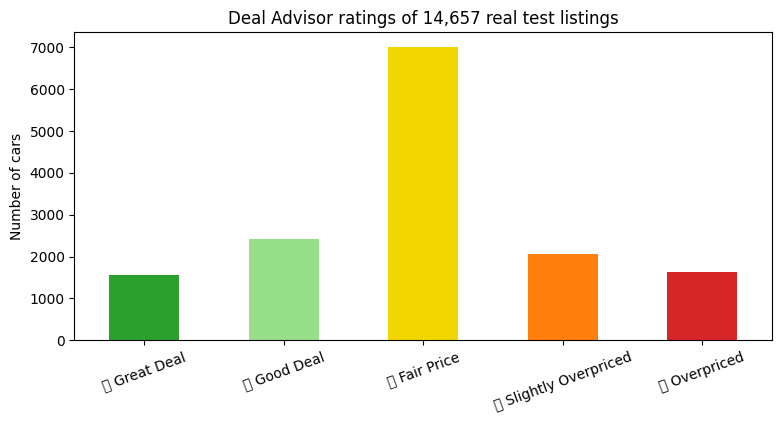

In [ ]:
order_labels = ["🟢 Great Deal", "🟢 Good Deal", "🟡 Fair Price", "🟠 Slightly Overpriced", "🔴 Overpriced"]
ratings = [deal_rating(p, s)[2] for p, s in zip(y_test_pred, y_test)]
rating_counts = pd.Series(ratings).value_counts().reindex(order_labels).fillna(0)
display((rating_counts / rating_counts.sum() * 100).round(1).to_frame("% of test listings"))

fig, ax = plt.subplots(figsize=(9, 4))
rating_counts.plot(kind="bar", ax=ax, color=["#2ca02c", "#98df8a", "#f2d600", "#ff7f0e", "#d62728"])
ax.set_title(f"Deal Advisor ratings of {len(y_test):,} real test listings")
ax.set_ylabel("Number of cars")
plt.xticks(rotation=20)
plt.show()

**Interpretation** (our run): **47.8%** of real listings are rated *Fair Price*; the rest is split almost evenly between the cheaper side (10.6% Great + 16.4% Good ≈ 27%) and the more expensive side (14.0% Slightly Overpriced + 11.1% Overpriced ≈ 25%). That is reasonable: dealers price near the market, and the remaining spread mirrors the model's typical error of ±5–6%.

**Practical lesson:** a “Great Deal” or “Overpriced” rating does *not* automatically mean a bargain or a rip-off — the model cannot see condition, trim level or history. Such cars deserve a closer look (and a vehicle-history check) before deciding.

# 15. Save the Model for the Streamlit App


In [ ]:
X_trval = pd.concat([X_train, X_val])
y_trval = pd.concat([y_train, y_val])

deploy_preprocessor = clone(preprocessor).fit(X_trval)
deploy_model = clone(final_model).fit(deploy_preprocessor.transform(X_trval), y_trval)

joblib.dump({"preprocessor": deploy_preprocessor, "model": deploy_model}, "autoworth_model.joblib")

def typical(series, fallback):
    value = series.median()
    return float(fallback if pd.isna(value) else value)

meta = {
    "models_by_make": {m: sorted(df[df["Make"] == m]["model"].unique().tolist()) for m in sorted(df["Make"].unique())},
    "transmissions": sorted(df["transmission"].unique().tolist()),
    "fuel_types": sorted(df["fuelType"].unique().tolist()),
    "defaults": {
        f"{mk}|{mo}": {
            "engineSize": typical(g["engineSize"], df["engineSize"].median()),
            "mpg": typical(g["mpg"], df["mpg"].median()),
            "tax": typical(g["tax"], df["tax"].median()),
            "fuelType": g["fuelType"].mode().iloc[0],
            "transmission": g["transmission"].mode().iloc[0],
        }
        for (mk, mo), g in df.groupby(["Make", "model"])
    },
}
with open("app_meta.json", "w") as f:
    json.dump(meta, f)
print("Saved: autoworth_model.joblib and app_meta.json")

try:                                   # on Colab: download both files to your computer
    from google.colab import files
    files.download("autoworth_model.joblib")
    files.download("app_meta.json")
except ImportError:
    pass

Saved: autoworth_model.joblib and app_meta.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>